# 🧠 Study Jam ML — Chapter 3 (Demo Notebook)

<div style="display:flex; gap:14px; align-items:center;">
  <div style="flex:1">
    <b>Theme:</b> From <i>ML-ready data</i> → <i>trained model</i><br/>
    <b>Flow:</b> Split → Anti-leakage → Pipeline → Metrics → Compare models → Mini demo imbalance (fraud)
  </div>
  <div style="width:220px">
    <img src="https://media.giphy.com/media/v1.Y2lkPTc5MGI3NjExbTZ0NGd4b2Y5b2Q2cWw5dGZpN3V5ZGdtdXo4dGZhd2p4dWhlcGg5NSZlcD12MV9naWZzX3NlYXJjaCZjdD1n/j6ZlX8ghxNFRknObVk/giphy.gif" width="220"/>
  </div>
</div>

---

## Table of Contents
- **Part 1:** Setup, split, and first pipeline  
- **Part 2:** Baseline + confusion matrix + metrics  
- **Part 3:** Train multiple models + fair comparison (+ optional CV)  
- **Part 4:** Mini demo imbalance (fraud) + solutions (class weight / threshold / resampling)

> Notebook ini dibuat untuk **Google Colab** dan dataset diambil langsung dari **Kaggle** via **Colab Secrets**.


In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score, classification_report
)
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [ ]:
!wget -O ps_train.csv https://raw.githubusercontent.com/maulnite/Study-Jam-ML-3/main/dataset/passenger_satisfaction/ps_train.csv
!wget -O ps_test.csv https://raw.githubusercontent.com/maulnite/Study-Jam-ML-3/main/dataset/passenger_satisfaction/ps_test.csv

--2026-03-10 12:21:59--  https://raw.githubusercontent.com/maulnite/Study-Jam-ML-3/main/dataset/passenger_satisfaction/ps_train.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 12089184 (12M) [text/plain]
Saving to: ‘ps_train.csv’

ps_train.csv        100%[===================>]  11.53M  --.-KB/s    in 0.03s   

2026-03-10 12:22:00 (355 MB/s) - ‘ps_train.csv’ saved [12089184/12089184]

--2026-03-10 12:22:00--  https://raw.githubusercontent.com/maulnite/Study-Jam-ML-3/main/dataset/passenger_satisfaction/ps_test.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.108.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, aw

In [ ]:
!wget -O fraud_train.csv https://raw.githubusercontent.com/maulnite/Study-Jam-ML-3/refs/heads/main/dataset/fraud_detection/fraud_train_small.csv
!wget -O fraud_test.csv https://raw.githubusercontent.com/maulnite/Study-Jam-ML-3/refs/heads/main/dataset/fraud_detection/fraud_test_small.csv

--2026-03-10 12:22:03--  https://raw.githubusercontent.com/maulnite/Study-Jam-ML-3/refs/heads/main/dataset/fraud_detection/fraud_train_small.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.108.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 53479828 (51M) [text/plain]
Saving to: ‘fraud_train.csv’

fraud_train.csv     100%[===================>]  51.00M  --.-KB/s    in 0.1s    

2026-03-10 12:22:03 (411 MB/s) - ‘fraud_train.csv’ saved [53479828/53479828]

--2026-03-10 12:22:04--  https://raw.githubusercontent.com/maulnite/Study-Jam-ML-3/refs/heads/main/dataset/fraud_detection/fraud_test_small.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... 

---
# Part 1: Setup, Split, dan Pipeline Pertama

**Tujuan:**
- Load dataset (airline) dari Github  
- Tentuin target **y** dan fitur **X**  
- Split train/validation pakai **stratify**  
- Bikin **Pipeline** pertama (preprocess + model)

> Output: `X_train, X_val, y_train, y_val` + `pipe_lr`


In [ ]:
# Load CSV (prefer train.csv if exists)
df = pd.read_csv('ps_train.csv')
display(df.head())


,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [ ]:
# Define target & features
TARGET_COL = "satisfaction"

id_like = [c for c in df.columns if c.lower() in ["id", "unnamed: 0"]]
X = df.drop(columns=[TARGET_COL] + id_like, errors="ignore")
y = df[TARGET_COL]

print("X shape:", X.shape, "| y shape:", y.shape)
print("Classes:", y.unique())


X shape: (103904, 22) | y shape: (103904,)
Classes: ['neutral or dissatisfied' 'satisfied']


### Sanity checks cepat
- Missing values  
- Distribusi target


In [ ]:
missing = X.isna().sum().sort_values(ascending=False)
display(missing[missing > 0].head(15))

counts = y.value_counts()
display(counts.to_frame("count"))
display((counts / counts.sum()).to_frame("ratio"))


,0
Arrival Delay in Minutes,310


,count
satisfaction,
neutral or dissatisfied,58879
satisfied,45025


,ratio
satisfaction,
neutral or dissatisfied,0.566667
satisfied,0.433333


In [ ]:
# Stratified split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train:", X_train.shape, "Val:", X_val.shape)
print("Train ratio:\n", y_train.value_counts(normalize=True).round(4))
print("Val ratio:\n", y_val.value_counts(normalize=True).round(4))


Train: (83123, 22) Val: (20781, 22)
Train ratio:
 satisfaction
neutral or dissatisfied    0.5667
satisfied                  0.4333
Name: proportion, dtype: float64
Val ratio:
 satisfaction
neutral or dissatisfied    0.5667
satisfied                  0.4333
Name: proportion, dtype: float64


### Feature types (numerical vs categorical)

In [ ]:
num_cols = X_train.select_dtypes(include=["number"]).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=["number"]).columns.tolist()

print("Numerical:", len(num_cols), "| Categorical:", len(cat_cols))
print("Sample num:", num_cols[:6])
print("Sample cat:", cat_cols[:6])


Numerical: 18 | Categorical: 4
Sample num: ['Age', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location']
Sample cat: ['Gender', 'Customer Type', 'Type of Travel', 'Class']


### Build Pipeline (anti leakage)
Preprocess:
- numeric: median imputer → scaler  
- categorical: most_frequent imputer → one-hot (ignore unseen categories)


In [ ]:
numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer([
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols)
])

pipe_lr = Pipeline([
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=1000))
])


In [ ]:
numeric_pipe

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])

In [ ]:
categorical_pipe

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('onehot', OneHotEncoder(handle_unknown='ignore'))])

In [ ]:
preprocess

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Age', 'Flight Distance',
                                  'Inflight wifi service',
                                  'Departure/Arrival time convenient',
                                  'Ease of Online booking', 'Gate location',
                                  'Food and drink', 'Online boarding',
                                  'Seat comfort', 'Inflight entertainment',
                                  'On-board service', 'Leg room service',
                                  'Baggage handling', 'Checkin service',
                                  'Inflight service', 'Cleanliness',
                                  'Departure Delay in Minutes',
                                  'Arrival Delay in Minutes']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['Gender', 'Customer Type', 'Type of Travel',
                                  'Class'])])

In [ ]:
pipe_lr

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Flight Distance',
                                                   'Inflight wifi service',
                                                   'Departure/Arrival time '
                                                   'convenient',
                                                   'Ease of Online booking',
                                                   'Gate location',
                                                   'Food and drink',
                                                   'Online boarding',
                                                   'Seat comfort',
                                                   'Inflight entertainment',
                                                   '...
                                                   'Leg room service',
                                                   'Baggage handling',
                                                   'Checkin service',
                                                   'Inflight service',
                                                   'Cleanliness',
                                                   'Departure Delay in Minutes',
                                                   'Arrival Delay in Minutes']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender', 'Customer Type',
                                                   'Type of Travel',
                                                   'Class'])])),
                ('model', LogisticRegression(max_iter=1000))])

---
# Part 2: Baseline + Confusion Matrix + Metrics


In [ ]:
def evaluate_clf(y_true, y_pred, title="Model"):
    print(f"=== {title} ===")
    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred, average="weighted", zero_division=0))
    print("Recall   :", recall_score(y_true, y_pred, average="weighted", zero_division=0))
    print("F1       :", f1_score(y_true, y_pred, average="weighted", zero_division=0))
    print("\nReport:\n", classification_report(y_true, y_pred, zero_division=0))

    cm = confusion_matrix(y_true, y_pred, labels=np.unique(y_true))
    ConfusionMatrixDisplay(cm, display_labels=np.unique(y_true)).plot(values_format="d")
    plt.title(f"Confusion Matrix — {title}")
    plt.show()


=== Baseline (Most Frequent) ===
Accuracy : 0.5666714787546316
Precision: 0.32111656483396095
Recall   : 0.5666714787546316
F1       : 0.4099347810802311

Report:
                          precision    recall  f1-score   support

neutral or dissatisfied       0.57      1.00      0.72     11776
              satisfied       0.00      0.00      0.00      9005

               accuracy                           0.57     20781
              macro avg       0.28      0.50      0.36     20781
           weighted avg       0.32      0.57      0.41     20781



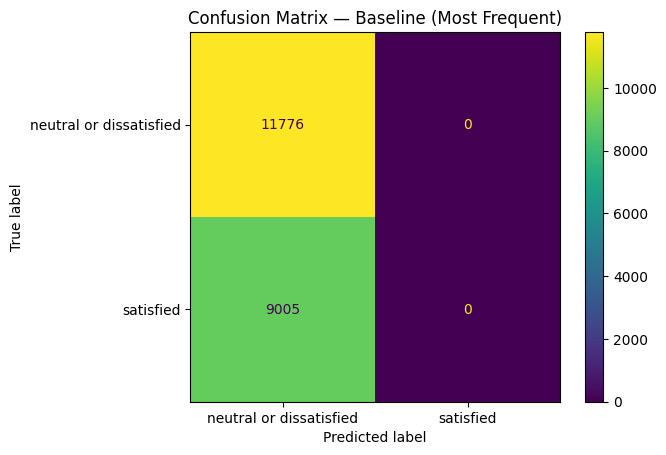

In [ ]:
# Baseline: most frequent
pipe_dummy = Pipeline([("preprocess", preprocess), ("model", DummyClassifier(strategy="most_frequent"))])
pipe_dummy.fit(X_train, y_train)
pred_dummy = pipe_dummy.predict(X_val)
evaluate_clf(y_val, pred_dummy, "Baseline (Most Frequent)")


=== Logistic Regression ===
Accuracy : 0.8765218228189211
Precision: 0.8763486100693421
Recall   : 0.8765218228189211
F1       : 0.8762682657968048

Report:
                          precision    recall  f1-score   support

neutral or dissatisfied       0.88      0.90      0.89     11776
              satisfied       0.87      0.84      0.86      9005

               accuracy                           0.88     20781
              macro avg       0.88      0.87      0.87     20781
           weighted avg       0.88      0.88      0.88     20781



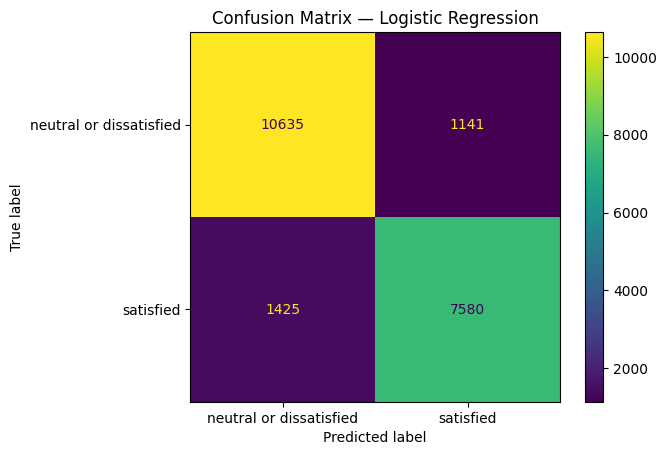

In [ ]:
# Logistic Regression
pipe_lr.fit(X_train, y_train)
pred_lr = pipe_lr.predict(X_val)
evaluate_clf(y_val, pred_lr, "Logistic Regression")


In [ ]:
print(pipe_lr.named_steps["model"].coef_)
print(pipe_lr.named_steps["model"].intercept_)

[[-0.12538141 -0.02159484  0.5295448  -0.18256149 -0.18834162  0.02164009
  -0.03317201  0.81880744  0.09549109  0.07975498  0.37956353  0.33616461
   0.16737919  0.4118824   0.14030016  0.28971608  0.17476799 -0.35062486
  -0.33540092 -0.30269831  0.70483695 -1.34293619  1.03272239 -1.67082163
   0.3298411  -0.41686948 -0.55107086]]
[-0.64218301]


---
# Part 3: Train Beberapa Model + Compare Secara Fair


In [ ]:
models = {
    "LogReg": Pipeline([("preprocess", preprocess), ("model", LogisticRegression(max_iter=1000))]),
    "DecisionTree": Pipeline([("preprocess", preprocess), ("model", DecisionTreeClassifier(random_state=RANDOM_STATE))]),
    "RandomForest": Pipeline([("preprocess", preprocess), ("model", RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1))]),
}

rows = []
for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_val)
    rows.append({
        "model": name,
        "accuracy": accuracy_score(y_val, pred),
        "precision_w": precision_score(y_val, pred, average="weighted", zero_division=0),
        "recall_w": recall_score(y_val, pred, average="weighted", zero_division=0),
        "f1_w": f1_score(y_val, pred, average="weighted", zero_division=0),
    })

leaderboard = pd.DataFrame(rows).sort_values("f1_w", ascending=False)
display(leaderboard)


,model,accuracy,precision_w,recall_w,f1_w
2,RandomForest,0.964246,0.964370,0.964246,0.964188
1,DecisionTree,0.945912,0.946089,0.945912,0.945958
0,LogReg,0.876522,0.876349,0.876522,0.876268


In [ ]:
best_name = leaderboard.iloc[0]["model"]
cv_pipe = models[best_name]

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(cv_pipe, X, y, cv=cv, scoring="f1_weighted")
print("Model for CV:", best_name)
print("CV scores:", cv_scores)
print("CV mean :", cv_scores.mean())


Model for CV: RandomForest
CV scores: [0.96249886 0.96314668 0.96064469]
CV mean : 0.9620967469618703


---
# Part 4: Mini Demo Imbalance (Fraud)

Dataset Kaggle: `kartik2112/fraud-detection`  
Target: `is_fraud` (1 = fraud, 0 = normal)

<img src="https://media.giphy.com/media/v1.Y2lkPTc5MGI3NjExZG9vZHF3cDFoZzM4Y3o2b3p6M2lydDdnbDdzc2F3bHF5M3B0Y2s2ZSZlcD12MV9naWZzX3NlYXJjaCZjdD1n/3o7aD2saalBwwftBIY/giphy.gif" width="420"/>


In [ ]:
usecols = ["trans_date_trans_time","category","amt","gender","state","city_pop","unix_time","is_fraud"]

df_f_train = pd.read_csv('fraud_train.csv', usecols=usecols)
df_f_test  = pd.read_csv('fraud_test.csv',  usecols=usecols)

print("Fraud rate train:", df_f_train["is_fraud"].mean(), "| test:", df_f_test["is_fraud"].mean())
display(df_f_train.head())


Fraud rate train: 0.03753 | test: 0.053625


,trans_date_trans_time,category,amt,gender,state,city_pop,unix_time,is_fraud
0,2019-02-16 07:57:26,gas_transport,53.64,M,OH,1831,1329379046,0
1,2020-02-04 02:33:36,entertainment,13.63,F,NY,10256,1359945216,0
2,2019-11-07 08:54:49,shopping_pos,4.86,F,NE,493,1352278489,0
3,2020-06-07 02:25:10,shopping_net,6.92,F,OR,260,1370571910,0
4,2020-04-13 10:24:16,gas_transport,89.48,F,WY,241,1365848656,0


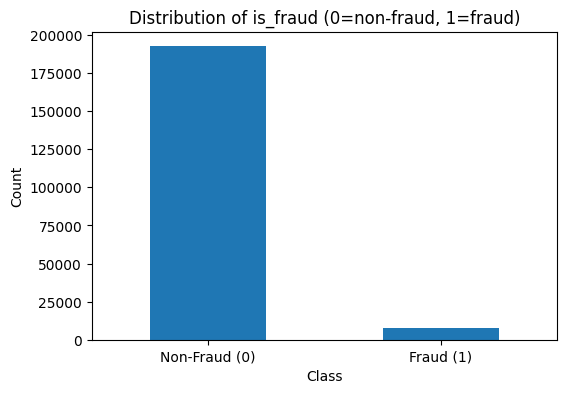

In [ ]:
counts_f = df_f_train['is_fraud'].value_counts()
plt.figure(figsize=(6, 4))
counts_f.plot(kind='bar')
plt.title('Distribution of is_fraud (0=non-fraud, 1=fraud)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['Non-Fraud (0)', 'Fraud (1)'], rotation=0)
plt.show()

In [ ]:
def fe_fraud(df):
    df = df.copy()
    df["trans_date_trans_time"] = pd.to_datetime(df["trans_date_trans_time"], errors="coerce")
    df["trans_hour"] = df["trans_date_trans_time"].dt.hour
    df["trans_dow"]  = df["trans_date_trans_time"].dt.dayofweek
    return df.drop(columns=["trans_date_trans_time"])

df_f_train = fe_fraud(df_f_train)

Xf = df_f_train.drop(columns=["is_fraud"])
yf = df_f_train["is_fraud"].astype(int)

Xf_tr, Xf_val, yf_tr, yf_val = train_test_split(Xf, yf, test_size=0.2, random_state=RANDOM_STATE, stratify=yf)
print("Fraud ratio train:", yf_tr.mean(), "| val:", yf_val.mean())


Fraud ratio train: 0.03753125 | val: 0.037525


### Accuracy Trap: baseline prediksi semua 0

Accuracy : 0.962475
Recall   : 0.0
Precision: 0.0
F1       : 0.0


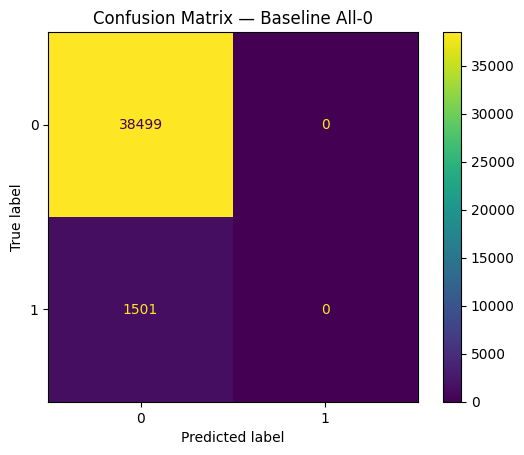

In [ ]:
pred_all0 = np.zeros_like(yf_val)
print("Accuracy :", accuracy_score(yf_val, pred_all0))
print("Recall   :", recall_score(yf_val, pred_all0, zero_division=0))
print("Precision:", precision_score(yf_val, pred_all0, zero_division=0))
print("F1       :", f1_score(yf_val, pred_all0, zero_division=0))

cm = confusion_matrix(yf_val, pred_all0, labels=[0,1])
ConfusionMatrixDisplay(cm, display_labels=[0,1]).plot(values_format="d")
plt.title("Confusion Matrix — Baseline All-0")
plt.show()


### Solusi 1: class_weight='balanced'

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Accuracy : 0.8798
Precision: 0.2014804116266474
Recall   : 0.7435043304463691
F1       : 0.3170454545454545


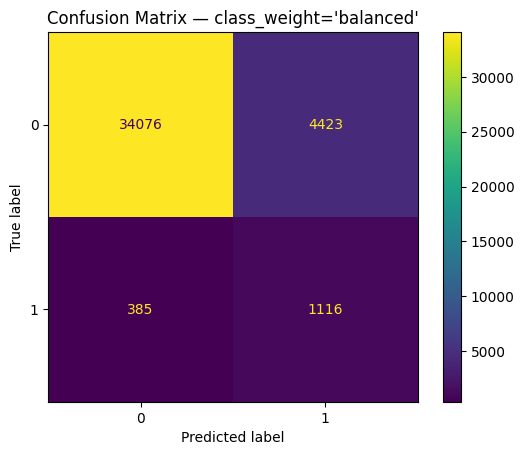

In [ ]:
num_f = Xf_tr.select_dtypes(include=["number"]).columns.tolist()
cat_f = Xf_tr.select_dtypes(exclude=["number"]).columns.tolist()

pre_f = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler())]), num_f),
    ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")), ("oh", OneHotEncoder(handle_unknown="ignore"))]), cat_f),
])

pipe_bal = Pipeline([
    ("preprocess", pre_f),
    ("model", LogisticRegression(max_iter=1000, solver="saga", class_weight="balanced"))
])

pipe_bal.fit(Xf_tr, yf_tr)
pred_bal = pipe_bal.predict(Xf_val)

print("Accuracy :", accuracy_score(yf_val, pred_bal))
print("Precision:", precision_score(yf_val, pred_bal, zero_division=0))
print("Recall   :", recall_score(yf_val, pred_bal, zero_division=0))
print("F1       :", f1_score(yf_val, pred_bal, zero_division=0))

cm = confusion_matrix(yf_val, pred_bal, labels=[0,1])
ConfusionMatrixDisplay(cm, display_labels=[0,1]).plot(values_format="d")
plt.title("Confusion Matrix — class_weight='balanced'")
plt.show()


### Solusi 2 (opsional): Threshold tuning

In [ ]:
proba = pipe_bal.predict_proba(Xf_val)[:, 1]

def metrics_at(t):
    pred = (proba >= t).astype(int)
    return {
        "threshold": t,
        "precision": precision_score(yf_val, pred, zero_division=0),
        "recall": recall_score(yf_val, pred, zero_division=0),
        "f1": f1_score(yf_val, pred, zero_division=0),
    }

df_thr = pd.DataFrame([metrics_at(t) for t in [0.5, 0.3, 0.2, 0.1]])
display(df_thr)


,threshold,precision,recall,f1
0,0.5,0.201480,0.743504,0.317045
1,0.3,0.100309,0.864757,0.179766
2,0.2,0.073468,0.953364,0.136422
3,0.1,0.054887,0.994004,0.104030


### Solusi 3: Under-sampling (resampling sederhana)

In [ ]:
df_tmp = Xf_tr.copy()
df_tmp["is_fraud"] = yf_tr.values

fraud = df_tmp[df_tmp["is_fraud"] == 1]
nonfraud = df_tmp[df_tmp["is_fraud"] == 0].sample(n=len(fraud), random_state=RANDOM_STATE)

df_under = pd.concat([fraud, nonfraud]).sample(frac=1, random_state=RANDOM_STATE)
Xu = df_under.drop(columns=["is_fraud"])
yu = df_under["is_fraud"].astype(int)

print("Under size:", len(df_under), "| fraud rate:", yu.mean())

pipe_under = Pipeline([("preprocess", pre_f), ("model", LogisticRegression(max_iter=1000, solver="saga"))])
pipe_under.fit(Xu, yu)
pred_under = pipe_under.predict(Xf_val)

print("Precision:", precision_score(yf_val, pred_under, zero_division=0))
print("Recall   :", recall_score(yf_val, pred_under, zero_division=0))
print("F1       :", f1_score(yf_val, pred_under, zero_division=0))


Under size: 12010 | fraud rate: 0.5
Precision: 0.20061505065123011
Recall   : 0.7388407728181212
F1       : 0.3155498648456395


---
# ⭐ Bonus: simpan dan gunakan model terbaik pakai `joblib`.


In [ ]:
import joblib
best_name = leaderboard.iloc[0]["model"]
best_pipe = models[best_name].fit(X_train, y_train)
joblib.dump(best_pipe, "best_airline_model.joblib")
print("✅ Saved best model:", best_name, "-> best_airline_model.joblib")

✅ Saved best model: RandomForest -> best_airline_model.joblib


In [ ]:
# Muat kembali model terbaik dari file
best_pipe_loaded = joblib.load("best_airline_model.joblib")

print("Model terbaik berhasil dimuat: ", best_pipe_loaded.named_steps['model'])

Model terbaik berhasil dimuat:  RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)


In [ ]:
X_test = pd.read_csv("ps_test.csv")
X_test = X_test.drop(columns=[TARGET_COL] + id_like, errors="ignore")
X_test.head()

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
0,Female,Loyal Customer,52,Business travel,Eco,160,5,4,3,4,...,3,5,5,5,5,2,5,5,50,44.0
1,Female,Loyal Customer,36,Business travel,Business,2863,1,1,3,1,...,5,4,4,4,4,3,4,5,0,0.0
2,Male,disloyal Customer,20,Business travel,Eco,192,2,0,2,4,...,2,2,4,1,3,2,2,2,0,0.0
3,Male,Loyal Customer,44,Business travel,Business,3377,0,0,0,2,...,4,1,1,1,1,3,1,4,0,6.0
4,Female,Loyal Customer,49,Business travel,Eco,1182,2,3,4,3,...,2,2,2,2,2,4,2,4,0,20.0


In [ ]:
# Buat prediksi pada data test
predictions_on_val = best_pipe_loaded.predict(X_test)

print("Prediksi berhasil dibuat. Berikut 5 prediksi pertama:")
print(predictions_on_val[:5])

# Jika ingin melihat probabilitas (untuk klasifikasi)
probabilities_on_val = best_pipe_loaded.predict_proba(X_val)
print("\nBerikut 5 probabilitas pertama (untuk setiap kelas):")
print(probabilities_on_val[:5])

Prediksi berhasil dibuat. Berikut 5 prediksi pertama:
['satisfied' 'satisfied' 'neutral or dissatisfied' 'satisfied'
 'neutral or dissatisfied']

Berikut 5 probabilitas pertama (untuk setiap kelas):
[[0.995 0.005]
 [0.975 0.025]
 [0.465 0.535]
 [0.97  0.03 ]
 [1.    0.   ]]
